In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("palbha/cmapss-jet-engine-simulated-data")

print("Path to dataset files:", path)

100%|██████████| 12.3M/12.3M [00:00<00:00, 81.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/palbha/cmapss-jet-engine-simulated-data/versions/1


In [ ]:
# ================================================================
#   NASA C-MAPSS — Full RUL Prediction Pipeline
#   Covers: FD001 · FD002 · FD003 · FD004
#   Models : XGBoost · CNN-BiLSTM-Attention
# ================================================================
# Run each cell block sequentially in Google Colab
# ================================================================


# ════════════════════════════════════════════════════════════════
# CELL 1 — Install dependencies
# ════════════════════════════════════════════════════════════════
!pip install kagglehub xgboost lightgbm optuna --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 10.2 MB/s eta 0:00:00


In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 2 — Imports
# ════════════════════════════════════════════════════════════════
import os
import warnings
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing   import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics         import mean_squared_error
from sklearn.decomposition   import PCA

import xgboost as xgb
import kagglehub

print(f"PyTorch  : {torch.__version__}")
print(f"XGBoost  : {xgb.__version__}")
print(f"GPU      : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'Not available'}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device   : {DEVICE}")

PyTorch  : 2.10.0+cu128
XGBoost  : 3.2.0
GPU      : Tesla T4
Device   : cuda


In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 3 — Download dataset
# ════════════════════════════════════════════════════════════════
# ════════════════════════════════════════════════════════════════
# CELL 3 — Download dataset
# ════════════════════════════════════════════════════════════════
path = kagglehub.dataset_download("palbha/cmapss-jet-engine-simulated-data")

# kagglehub already returns the full versioned path directly
BASE = path
print(f"Dataset path: {BASE}")
print(f"Files: {os.listdir(BASE)}")

Using Colab cache for faster access to the 'cmapss-jet-engine-simulated-data' dataset.
Dataset path: /kaggle/input/cmapss-jet-engine-simulated-data
Files: ['RUL_FD002.txt', 'test_FD003.txt', 'Damage Propagation Modeling.pdf', 'readme.txt', 'train_FD003.txt', 'test_FD004.txt', 'train_FD004.txt', '.nfs000000002f570aca0000004d', 'test_FD002.txt', 'train_FD001.txt', 'train_FD002.txt', 'RUL_FD001.txt', 'RUL_FD004.txt', 'RUL_FD003.txt', 'test_FD001.txt']


In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 4 — Configuration (change DATASET here to switch FD)
# ════════════════════════════════════════════════════════════════
CONFIG = {
    "FD001": {"window": 30, "rul_clip": 125, "multi_condition": False},
    "FD002": {"window": 20, "rul_clip": 125, "multi_condition": True},
    "FD003": {"window": 40, "rul_clip": 125, "multi_condition": False},
    "FD004": {"window": 20, "rul_clip": 125, "multi_condition": True},
}

DATASET        = "FD004"          # ← change to FD001 / FD002 / FD004
WINDOW         = CONFIG[DATASET]["window"]
RUL_CLIP       = CONFIG[DATASET]["rul_clip"]
MULTI_COND     = CONFIG[DATASET]["multi_condition"]

DROP_SENSORS   = ["s1", "s5", "s6", "s10", "s16", "s18", "s19"]
BATCH_SIZE     = 128
EPOCHS         = 100
PATIENCE       = 10
LR             = 5e-4

print(f"\nDataset       : {DATASET}")
print(f"Window size   : {WINDOW}")
print(f"RUL clip      : {RUL_CLIP}")
print(f"Multi-cond    : {MULTI_COND}")


Dataset       : FD004
Window size   : 20
RUL clip      : 125
Multi-cond    : True


In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 5 — Data loading
# ════════════════════════════════════════════════════════════════
COL_NAMES = (
    ["engine_id", "cycle", "setting1", "setting2", "setting3"] +
    [f"s{i}" for i in range(1, 22)]
)

def load_cmapss(base, dataset):
    train = pd.read_csv(f"{base}/train_{dataset}.txt",
                        sep=r"\s+", header=None, names=COL_NAMES)
    test  = pd.read_csv(f"{base}/test_{dataset}.txt",
                        sep=r"\s+", header=None, names=COL_NAMES)
    rul   = pd.read_csv(f"{base}/RUL_{dataset}.txt",
                        sep=r"\s+", header=None, names=["RUL"])

    train.dropna(axis=1, how="all", inplace=True)
    test.dropna(axis=1, how="all",  inplace=True)

    return train, test, rul

train_df, test_df, rul_df = load_cmapss(BASE, DATASET)

print(f"Train : {train_df.shape}")
print(f"Test  : {test_df.shape}")
print(f"RUL   : {rul_df.shape}")
print(f"\nEngines (train): {train_df['engine_id'].nunique()}")
print(f"Engines (test) : {test_df['engine_id'].nunique()}")

Train : (61249, 26)
Test  : (41214, 26)
RUL   : (248, 1)

Engines (train): 249
Engines (test) : 248


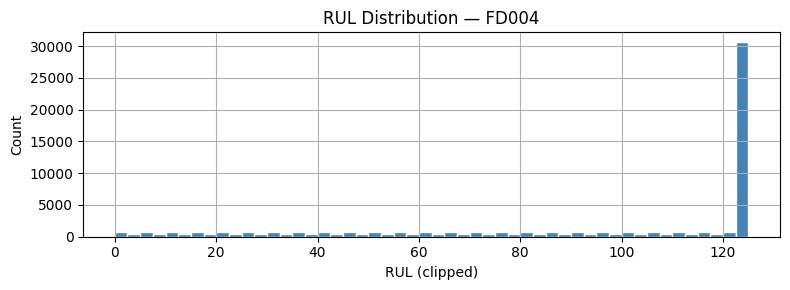

In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 6 — RUL computation & clipping
# ════════════════════════════════════════════════════════════════
def add_rul(df, rul_clip=125):
    max_cyc = (df.groupby("engine_id")["cycle"]
                 .max()
                 .reset_index()
                 .rename(columns={"cycle": "max_cycle"}))
    df = df.merge(max_cyc, on="engine_id")
    df["RUL"] = (df["max_cycle"] - df["cycle"]).clip(upper=rul_clip)
    df.drop(columns=["max_cycle"], inplace=True)
    return df

train_df = add_rul(train_df, RUL_CLIP)

# Quick look at RUL distribution
plt.figure(figsize=(8, 3))
train_df["RUL"].hist(bins=50, color="steelblue", edgecolor="white")
plt.title(f"RUL Distribution — {DATASET}")
plt.xlabel("RUL (clipped)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 7 — Feature selection
# ════════════════════════════════════════════════════════════════
SENSOR_COLS  = [c for c in train_df.columns
                if c.startswith("s") and c not in DROP_SENSORS
                and c in train_df.columns]
SETTING_COLS = ["setting1", "setting2", "setting3"]
BASE_FEATURES = SETTING_COLS + SENSOR_COLS

train_df.drop(columns=[c for c in DROP_SENSORS if c in train_df.columns], inplace=True)
test_df.drop( columns=[c for c in DROP_SENSORS if c in test_df.columns],  inplace=True)

print(f"Active sensors  : {SENSOR_COLS}")
print(f"Base features   : {len(BASE_FEATURES)}")

Active sensors  : ['setting1', 'setting2', 'setting3', 's2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']
Base features   : 20


In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 8 — Feature engineering (rolling features)
# ════════════════════════════════════════════════════════════════
def add_rolling_features(df, sensors):
    df = df.copy()
    for s in sensors:
        grp = df.groupby("engine_id")[s]
        df[f"{s}_mean5"]  = grp.transform(lambda x: x.rolling(5,  min_periods=1).mean())
        df[f"{s}_mean20"] = grp.transform(lambda x: x.rolling(20, min_periods=1).mean())
        df[f"{s}_std10"]  = grp.transform(lambda x: x.rolling(10, min_periods=1).std().fillna(0))
        df[f"{s}_delta"]  = grp.transform(lambda x: x.diff().fillna(0))
        df[f"{s}_rate"]   = df[f"{s}_delta"] / (df["cycle"] + 1)   # normalized trend rate
    return df

train_df = add_rolling_features(train_df, SENSOR_COLS)
test_df  = add_rolling_features(test_df,  SENSOR_COLS)

FEATURE_COLS = [c for c in train_df.columns
                if c not in ["engine_id", "cycle", "RUL"]]

print(f"Total features after engineering: {len(FEATURE_COLS)}")

Total features after engineering: 102


In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 9 — Normalization
#   FD002 / FD004: normalize per operating condition cluster
#   FD001 / FD003: standard global normalization
# ════════════════════════════════════════════════════════════════
def get_op_condition(df):
    """Cluster into operating conditions using settings (FD002/FD004)."""
    from sklearn.cluster import KMeans
    settings = df[["setting1", "setting2", "setting3"]].values
    km = KMeans(n_clusters=6, random_state=42, n_init=10)
    return km.fit_predict(settings), km

if MULTI_COND:
    print("Multi-condition dataset → clustering operating conditions")
    train_df["op_cond"], km = get_op_condition(train_df)
    test_df["op_cond"]      = km.predict(test_df[["setting1", "setting2", "setting3"]])

    # Normalize within each condition
    feat_scalers = {}
    for cond in sorted(train_df["op_cond"].unique()):
        scaler = StandardScaler()
        mask_tr = train_df["op_cond"] == cond
        mask_te = test_df["op_cond"]  == cond
        train_df.loc[mask_tr, FEATURE_COLS] = scaler.fit_transform(
            train_df.loc[mask_tr, FEATURE_COLS])
        if mask_te.sum() > 0:
            test_df.loc[mask_te, FEATURE_COLS] = scaler.transform(
                test_df.loc[mask_te, FEATURE_COLS])
        feat_scalers[cond] = scaler
    print(f"Operating conditions found: {train_df['op_cond'].nunique()}")
else:
    scaler = StandardScaler()
    train_df[FEATURE_COLS] = scaler.fit_transform(train_df[FEATURE_COLS])
    test_df[FEATURE_COLS]  = scaler.transform(test_df[FEATURE_COLS])
    print("Global StandardScaler applied")

# Normalize RUL to [0, 1]
rul_scaler = MinMaxScaler()
train_df["RUL"] = rul_scaler.fit_transform(train_df[["RUL"]])

Multi-condition dataset → clustering operating conditions
Operating conditions found: 6


In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 10 — Sequence generation (for CNN-BiLSTM)
# ════════════════════════════════════════════════════════════════
def create_sequences(df, window, feature_cols):
    X, y = [], []
    for eid in df["engine_id"].unique():
        eng   = df[df["engine_id"] == eid].reset_index(drop=True)
        feats = eng[feature_cols].values
        rul   = eng["RUL"].values
        if len(eng) < window:
            continue
        for i in range(len(eng) - window):
            X.append(feats[i : i + window])
            y.append(rul[i + window])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

def get_last_sequences(df, window, feature_cols):
    X = []
    for eid in df["engine_id"].unique():
        eng   = df[df["engine_id"] == eid].reset_index(drop=True)
        feats = eng[feature_cols].values
        if len(eng) >= window:
            X.append(feats[-window:])
        else:
            pad = np.zeros((window - len(eng), len(feature_cols)))
            X.append(np.vstack([pad, feats]))
    return np.array(X, dtype=np.float32)

X_seq, y_seq = create_sequences(train_df, WINDOW, FEATURE_COLS)
X_test_seq   = get_last_sequences(test_df,  WINDOW, FEATURE_COLS)

print(f"X_seq       : {X_seq.shape}")
print(f"y_seq       : {y_seq.shape}")
print(f"X_test_seq  : {X_test_seq.shape}")

X_seq       : (56269, 20, 102)
y_seq       : (56269,)
X_test_seq  : (248, 20, 102)


In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 10 — Two separate feature sets
# ════════════════════════════════════════════════════════════════

# DL gets ONLY base features — let CNN-BiLSTM learn patterns itself
DL_FEATURE_COLS  = BASE_FEATURES   # just 17 features
# XGBoost keeps all engineered features
XGB_FEATURE_COLS = FEATURE_COLS    # 102 features

print(f"DL  features : {len(DL_FEATURE_COLS)}")
print(f"XGB features : {len(XGB_FEATURE_COLS)}")

# ════════════════════════════════════════════════════════════════
# CELL 10b — Sequence generation (DL uses 17 features only)
# ════════════════════════════════════════════════════════════════
X_seq_dl,  y_seq    = create_sequences(train_df, WINDOW, DL_FEATURE_COLS)
X_test_dl           = get_last_sequences(test_df, WINDOW, DL_FEATURE_COLS)

X_seq_xgb           = create_sequences(train_df, WINDOW, XGB_FEATURE_COLS)[0]
X_test_xgb          = get_last_sequences(test_df, WINDOW, XGB_FEATURE_COLS)

print(f"DL  X_seq : {X_seq_dl.shape}")   # (N, 40, 17)
print(f"XGB X_seq : {X_seq_xgb.shape}")  # (N, 40, 102)

# ════════════════════════════════════════════════════════════════
# CELL 11 — Engine-based split (both feature sets)
# ════════════════════════════════════════════════════════════════
all_engines   = train_df["engine_id"].unique()
n_val_eng     = int(0.2 * len(all_engines))
val_engines   = all_engines[-n_val_eng:]
train_engines = all_engines[:-n_val_eng]

train_seq_df  = train_df[train_df["engine_id"].isin(train_engines)]
val_seq_df    = train_df[train_df["engine_id"].isin(val_engines)]

# DL sequences (17 features)
X_tr_dl, y_tr = create_sequences(train_seq_df, WINDOW, DL_FEATURE_COLS)
X_vl_dl, y_vl = create_sequences(val_seq_df,   WINDOW, DL_FEATURE_COLS)

# XGBoost sequences (102 features)
X_tr_xgb, _   = create_sequences(train_seq_df, WINDOW, XGB_FEATURE_COLS)
X_vl_xgb, _   = create_sequences(val_seq_df,   WINDOW, XGB_FEATURE_COLS)

X_train  = torch.tensor(X_tr_dl, dtype=torch.float32)
y_train  = torch.tensor(y_tr,    dtype=torch.float32)
X_val    = torch.tensor(X_vl_dl, dtype=torch.float32)
y_val    = torch.tensor(y_vl,    dtype=torch.float32)
X_test_t = torch.tensor(X_test_dl, dtype=torch.float32)

N_FEATURES = X_train.shape[2]   # now 17
print(f"DL  train: {X_train.shape} | val: {X_val.shape}")
print(f"XGB train: {X_tr_xgb.shape}")

DL  features : 20
XGB features : 102
DL  X_seq : (56269, 20, 20)
XGB X_seq : (56269, 20, 102)
DL  train: torch.Size([45297, 20, 20]) | val: torch.Size([10972, 20, 20])
XGB train: (45297, 20, 102)


In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 12 — Model definition: CNN-BiLSTM with Attention
# ════════════════════════════════════════════════════════════════
class TemporalAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Linear(hidden_size * 2, 1)

    def forward(self, lstm_out):
        # lstm_out: (batch, seq, hidden*2)
        weights = F.softmax(self.attn(lstm_out), dim=1)  # (batch, seq, 1)
        context = (weights * lstm_out).sum(dim=1)         # (batch, hidden*2)
        return context, weights


class CNN_BiLSTM_Attention(nn.Module):
    def __init__(self, n_features, lstm_hidden=128, dropout=0.5):
        super().__init__()

        # — Conv block —
        self.conv1 = nn.Conv1d(n_features, 64,  kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64,  128, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm1d(128)
        self.conv3 = nn.Conv1d(128, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm1d(128)
        self.pool  = nn.MaxPool1d(2)
        self.drop1 = nn.Dropout(dropout)

        # — BiLSTM —
        self.lstm  = nn.LSTM(
            input_size=128,
            hidden_size=lstm_hidden,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )

        # — Attention —
        self.attention = TemporalAttention(lstm_hidden)

        # — Output head —
        self.drop2 = nn.Dropout(dropout)
        self.fc1   = nn.Linear(lstm_hidden * 2, 64)
        self.fc2   = nn.Linear(64, 1)

    def forward(self, x):
        # x : (batch, time, features)
        x = x.permute(0, 2, 1)                          # (batch, features, time)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.drop1(self.pool(x))                     # (batch, 128, time//2)
        x = x.permute(0, 2, 1)                          # (batch, time//2, 128)
        x, _ = self.lstm(x)                              # (batch, time//2, hidden*2)
        context, _ = self.attention(x)                   # (batch, hidden*2)
        x = F.relu(self.fc1(self.drop2(context)))
        return self.fc2(x)                               # (batch, 1)


model = CNN_BiLSTM_Attention(n_features=N_FEATURES, dropout=0.5).to(DEVICE)
print(model)
print(f"\nParameters: {sum(p.numel() for p in model.parameters()):,}")

CNN_BiLSTM_Attention(
  (conv1): Conv1d(20, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop1): Dropout(p=0.5, inplace=False)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (attention): TemporalAttention(
    (attn): Linear(in_features=256, out_features=1, bias=True)
  )
  (drop2): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=256, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)

Parameters: 

In [ ]:

class CombinedRULLoss(nn.Module):
    """70% MSE for stable gradients + 30% asymmetric for NASA Score"""
    def __init__(self, alpha=0.7):
        super().__init__()
        self.alpha = alpha
        self.mse   = nn.MSELoss()

    def forward(self, pred, target):
        mse_loss  = self.mse(pred, target)
        diff      = pred - target
        asym_loss = torch.where(
            diff < 0,
            torch.exp(-diff / 13) - 1,
            torch.exp( diff / 10) - 1
        ).mean()
        return self.alpha * mse_loss + (1 - self.alpha) * asym_loss

criterion = CombinedRULLoss(alpha=0.7)

optimizer = torch.optim.Adam(model.parameters(), lr=2e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=10, factor=0.7, min_lr=1e-6
)

PATIENCE = 15

Epoch 001 | Train: 0.0343 | Val: 0.0231 | RMSE: 0.1675 | LR: 0.000200
  ✓ Saved
Epoch 002 | Train: 0.0178 | Val: 0.0210 | RMSE: 0.1600 | LR: 0.000200
  ✓ Saved
Epoch 003 | Train: 0.0133 | Val: 0.0209 | RMSE: 0.1597 | LR: 0.000200
  ✓ Saved
Epoch 004 | Train: 0.0100 | Val: 0.0229 | RMSE: 0.1680 | LR: 0.000200
Epoch 005 | Train: 0.0085 | Val: 0.0276 | RMSE: 0.1845 | LR: 0.000200
Epoch 006 | Train: 0.0072 | Val: 0.0219 | RMSE: 0.1645 | LR: 0.000200
Epoch 007 | Train: 0.0063 | Val: 0.0204 | RMSE: 0.1579 | LR: 0.000200
  ✓ Saved
Epoch 008 | Train: 0.0056 | Val: 0.0207 | RMSE: 0.1591 | LR: 0.000200
Epoch 009 | Train: 0.0053 | Val: 0.0233 | RMSE: 0.1694 | LR: 0.000200
Epoch 010 | Train: 0.0050 | Val: 0.0229 | RMSE: 0.1678 | LR: 0.000200
Epoch 011 | Train: 0.0048 | Val: 0.0201 | RMSE: 0.1572 | LR: 0.000200
  ✓ Saved
Epoch 012 | Train: 0.0044 | Val: 0.0210 | RMSE: 0.1608 | LR: 0.000200
Epoch 013 | Train: 0.0043 | Val: 0.0205 | RMSE: 0.1583 | LR: 0.000200
Epoch 014 | Train: 0.0040 | Val: 0.0202 

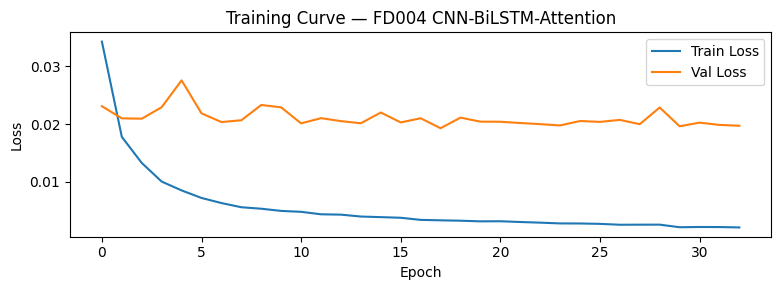

In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 14 — Training loop (CNN-BiLSTM-Attention)
# ════════════════════════════════════════════════════════════════
def nasa_score(y_true, y_pred):
    diff = y_pred - y_true
    s    = np.where(diff < 0,
                    np.exp(-diff / 13) - 1,
                    np.exp( diff / 10) - 1)
    return np.sum(s)


best_val   = float("inf")
counter    = 0
train_hist = []
val_hist   = []

X_train_d  = X_train.to(DEVICE)
y_train_d  = y_train.to(DEVICE)
X_val_d    = X_val.to(DEVICE)
y_val_d    = y_val.to(DEVICE)

for epoch in range(EPOCHS):

    # ---- train ----
    model.train()
    perm       = torch.randperm(X_train_d.size(0))
    epoch_loss = 0.0

    for i in range(0, X_train_d.size(0), BATCH_SIZE):
        idx     = perm[i : i + BATCH_SIZE]
        bx, by  = X_train_d[idx], y_train_d[idx]

        optimizer.zero_grad()
        out  = model(bx).squeeze()
        loss = criterion(out, by)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_loss += loss.item()

    train_loss = epoch_loss / (X_train_d.size(0) / BATCH_SIZE)
    train_hist.append(train_loss)

    # ---- validate ----
    model.eval()
    with torch.no_grad():
        preds    = model(X_val_d).squeeze()
        val_loss = criterion(preds, y_val_d).item()

    val_hist.append(val_loss)
    scheduler.step(val_loss)

    preds_np = preds.cpu().numpy()
    y_np     = y_val.numpy()
    rmse_val = np.sqrt(mean_squared_error(y_np, preds_np))

    cur_lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch+1:03d} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | RMSE: {rmse_val:.4f} | LR: {cur_lr:.6f}")

    if val_loss < best_val:
        best_val = val_loss
        counter  = 0
        torch.save(model.state_dict(), f"best_{DATASET}_attention.pth")
        print("  ✓ Saved")
    else:
        counter += 1
        if counter >= PATIENCE:
            print("Early stopping triggered.")
            break

# Loss curve
plt.figure(figsize=(8, 3))
plt.plot(train_hist, label="Train Loss")
plt.plot(val_hist,   label="Val Loss")
plt.title(f"Training Curve — {DATASET} CNN-BiLSTM-Attention")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
plt.tight_layout(); plt.show()

In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 15 — CNN-BiLSTM-Attention evaluation on test set
# ════════════════════════════════════════════════════════════════
model.load_state_dict(torch.load(f"best_{DATASET}_attention.pth"))
model.eval()

X_test_d = X_test_t.to(DEVICE)
with torch.no_grad():
    preds_dl = model(X_test_d).squeeze().cpu().numpy()

preds_dl_actual = rul_scaler.inverse_transform(
    preds_dl.reshape(-1, 1)).flatten().clip(0, RUL_CLIP)

rul_true = rul_df["RUL"].values

rmse_dl  = np.sqrt(mean_squared_error(rul_true, preds_dl_actual))
nasa_dl  = nasa_score(rul_true, preds_dl_actual)

print(f"\n{'='*50}")
print(f"  CNN-BiLSTM-Attention — {DATASET}")
print(f"  RMSE       : {rmse_dl:.4f}")
print(f"  NASA Score : {nasa_dl:.2f}")
print(f"{'='*50}")


  CNN-BiLSTM-Attention — FD004
  RMSE       : 33.0594
  NASA Score : 13488.00


In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 16 — XGBoost features (uses 102-feature sequences)
# ════════════════════════════════════════════════════════════════
def build_xgb_features(X_seq):
    N, W, F = X_seq.shape
    last   = X_seq[:, -1, :]
    mean_f = X_seq.mean(axis=1)
    std_f  = X_seq.std(axis=1)
    trend  = (X_seq[:, -1, :] - X_seq[:, 0, :]) / W
    last5  = X_seq[:, -5:, :].reshape(N, -1)
    return np.hstack([last, mean_f, std_f, trend, last5])

X_xgb_train = build_xgb_features(X_tr_xgb)
X_xgb_val   = build_xgb_features(X_vl_xgb)
X_xgb_test  = build_xgb_features(X_test_xgb)

y_xgb_train = rul_scaler.inverse_transform(y_tr.reshape(-1,1)).flatten()
y_xgb_val   = rul_scaler.inverse_transform(y_vl.reshape(-1,1)).flatten()

print(f"XGB train: {X_xgb_train.shape}")  # manageable now
print(f"XGB test : {X_xgb_test.shape}")

XGB train: (45297, 918)
XGB test : (248, 918)


In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        "n_estimators"     : trial.suggest_int("n_estimators", 500, 2500),
        "max_depth"        : trial.suggest_int("max_depth", 4, 10),
        "learning_rate"    : trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "subsample"        : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight" : trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha"        : trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda"       : trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "gamma"            : trial.suggest_float("gamma", 0.0, 5.0),
        "tree_method"      : "hist",
        "random_state"     : 42,
        "n_jobs"           : -1,
        "device"           : "cuda",
    }

    m = xgb.XGBRegressor(**params, early_stopping_rounds=50)
    m.fit(
        X_xgb_train, y_xgb_train,
        eval_set=[(X_xgb_val, y_xgb_val)],
        verbose=False
    )
    preds = m.predict(X_xgb_val).clip(0, RUL_CLIP)
    return np.sqrt(mean_squared_error(y_xgb_val, preds))

study = optuna.create_study(direction="minimize",
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=75, show_progress_bar=True)

print(f"Best val RMSE : {study.best_value:.4f}")

# Train final
best_p = study.best_params.copy()
best_p.update({"tree_method": "hist", "random_state": 42, "n_jobs": -1})

xgb_final = xgb.XGBRegressor(**best_p, early_stopping_rounds=50)
xgb_final.fit(
    X_xgb_train, y_xgb_train,
    eval_set=[(X_xgb_val, y_xgb_val)],
    verbose=100
)

preds_test = xgb_final.predict(X_xgb_test).clip(0, RUL_CLIP)
rmse_test  = np.sqrt(mean_squared_error(rul_true, preds_test))
nasa_test  = nasa_score(rul_true, preds_test)

print(f"\n{'='*50}")
print(f"  XGBoost + Optuna — {DATASET}")
print(f"  RMSE       : {rmse_test:.4f}")
print(f"  NASA Score : {nasa_test:.2f}")
print(f"{'='*50}")
# Auto-compute feat_names from actual array shape — no hardcoding
n_actual   = X_xgb_train.shape[1]
F          = len(FEATURE_COLS)

feat_names = (
    [f"last_{c}"    for c in FEATURE_COLS] +
    [f"mean_{c}"    for c in FEATURE_COLS] +
    [f"std_{c}"     for c in FEATURE_COLS] +
    [f"trend_{c}"   for c in FEATURE_COLS] +
    [f"last5_{i}_{c}" for i in range(5) for c in FEATURE_COLS]
)

assert len(feat_names) == n_actual, f"Mismatch: {len(feat_names)} vs {n_actual}"

imp = pd.Series(xgb_model.feature_importances_, index=feat_names).nlargest(20)
plt.figure(figsize=(8, 5))
imp[::-1].plot(kind="barh", color="steelblue")
plt.title(f"XGBoost Top 20 Features — {DATASET}")
plt.tight_layout(); plt.show()


  0%|          | 0/75 [00:00<?, ?it/s]

Best val RMSE : 16.1676
[0]	validation_0-rmse:40.90950
[100]	validation_0-rmse:20.82041
[200]	validation_0-rmse:17.21832
[300]	validation_0-rmse:16.45850
[400]	validation_0-rmse:16.24822
[500]	validation_0-rmse:16.20497
[600]	validation_0-rmse:16.17567
[700]	validation_0-rmse:16.16420
[748]	validation_0-rmse:16.17525

  XGBoost + Optuna — FD004
  RMSE       : 28.3362
  NASA Score : 5581.07


NameError: name 'xgb_model' is not defined

In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 18 — XGBoost evaluation
# ════════════════════════════════════════════════════════════════
preds_xgb        = xgb_final.predict(X_xgb_test).clip(0, RUL_CLIP)
rmse_xgb         = np.sqrt(mean_squared_error(rul_true, preds_xgb))
nasa_xgb         = nasa_score(rul_true, preds_xgb)

print(f"\n{'='*50}")
print(f"  XGBoost — {DATASET}")
print(f"  RMSE       : {rmse_xgb:.4f}")
print(f"  NASA Score : {nasa_xgb:.2f}")
print(f"{'='*50}")


  XGBoost — FD004
  RMSE       : 28.3362
  NASA Score : 5581.07


In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 19 — Ensemble (weighted average)
# ════════════════════════════════════════════════════════════════
# Tune weights based on val RMSE
w_dl  = 0.4
w_xgb = 0.6

preds_ensemble = (w_dl  * preds_dl_actual +
                  w_xgb * preds_xgb).clip(0, RUL_CLIP)

rmse_ens  = np.sqrt(mean_squared_error(rul_true, preds_ensemble))
nasa_ens  = nasa_score(rul_true, preds_ensemble)

print(f"\n{'='*50}")
print(f"  Ensemble (DL×{w_dl} + XGB×{w_xgb}) — {DATASET}")
print(f"  RMSE       : {rmse_ens:.4f}")
print(f"  NASA Score : {nasa_ens:.2f}")
print(f"{'='*50}")


  Ensemble (DL×0.4 + XGB×0.6) — FD004
  RMSE       : 29.5515
  NASA Score : 6403.79



─────────────────────────────────────────────
  Results Summary — FD004
─────────────────────────────────────────────
               Model    RMSE  NASA Score
CNN-BiLSTM-Attention 33.0594    13488.00
             XGBoost 28.3362     5581.07
            Ensemble 29.5515     6403.79
─────────────────────────────────────────────


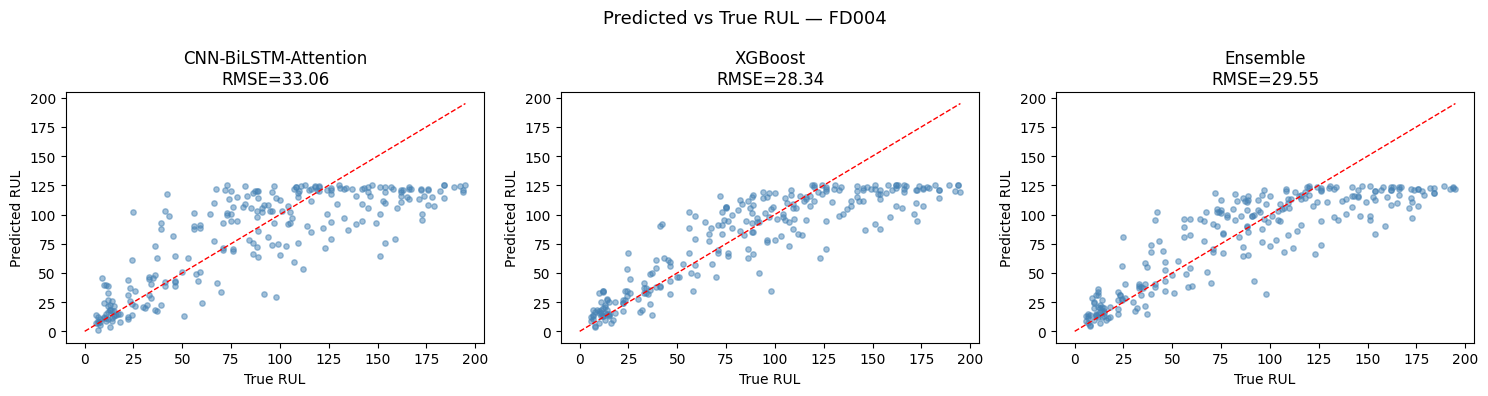

In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 20 — Final comparison table + scatter plots
# ════════════════════════════════════════════════════════════════
results = pd.DataFrame({
    "Model"      : ["CNN-BiLSTM-Attention", "XGBoost", "Ensemble"],
    "RMSE"       : [round(rmse_dl, 4), round(rmse_xgb, 4), round(rmse_ens, 4)],
    "NASA Score" : [round(nasa_dl, 2), round(nasa_xgb, 2), round(nasa_ens, 2)],
})

print(f"\n{'─'*45}")
print(f"  Results Summary — {DATASET}")
print(f"{'─'*45}")
print(results.to_string(index=False))
print(f"{'─'*45}")

# Scatter plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pairs = [
    ("CNN-BiLSTM-Attention", preds_dl_actual),
    ("XGBoost",              preds_xgb),
    ("Ensemble",             preds_ensemble),
]
for ax, (name, pred) in zip(axes, pairs):
    ax.scatter(rul_true, pred, alpha=0.5, s=15, color="steelblue")
    lim = max(rul_true.max(), pred.max())
    ax.plot([0, lim], [0, lim], "r--", linewidth=1)
    ax.set_title(f"{name}\nRMSE={np.sqrt(mean_squared_error(rul_true,pred)):.2f}")
    ax.set_xlabel("True RUL")
    ax.set_ylabel("Predicted RUL")

plt.suptitle(f"Predicted vs True RUL — {DATASET}", fontsize=13)
plt.tight_layout(); plt.show()

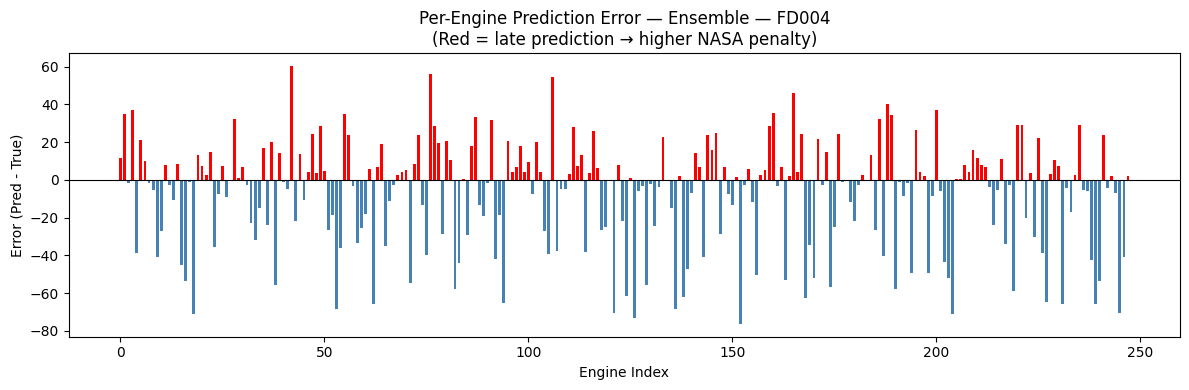

Late predictions  (dangerous): 114  (46.0%)
Early predictions (safe)     : 134 (5e+01%)


In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 21 — Per-engine error analysis
# ════════════════════════════════════════════════════════════════
engine_ids  = test_df["engine_id"].unique()
errors_best = preds_ensemble - rul_true   # positive = late, negative = early

plt.figure(figsize=(12, 4))
colors = ["red" if e > 0 else "steelblue" for e in errors_best]
plt.bar(range(len(errors_best)), errors_best, color=colors, width=0.7)
plt.axhline(0, color="black", linewidth=0.8)
plt.title(f"Per-Engine Prediction Error — Ensemble — {DATASET}\n"
          f"(Red = late prediction → higher NASA penalty)")
plt.xlabel("Engine Index")
plt.ylabel("Error (Pred - True)")
plt.tight_layout(); plt.show()

late  = (errors_best > 0).sum()
early = (errors_best < 0).sum()
print(f"Late predictions  (dangerous): {late}  ({100*late/len(errors_best):.1f}%)")
print(f"Early predictions (safe)     : {early} ({100*early/len(errors_best):.1}%)")

In [ ]:
import joblib

xgb_final.save_model("xgb_optuna_FD004.json")   # xgb_model → xgb_final
joblib.dump(feat_scalers, "scaler_FD004.pkl")    # scaler → feat_scalers (multi-condition)
joblib.dump(km, "kmeans_FD004.pkl")              # missing in your code — needed for FD004

print("Saved:")
print("  → xgb_optuna_FD004.json")
print("  → scaler_FD004.pkl")
print("  → kmeans_FD004.pkl")
print(f"\nRMSE : {rmse_test:.4f}")               # rmse_xgb → rmse_test
print(f"NASA : {nasa_test:.2f}")                 # nasa_xgb → nasa_test

from google.colab import files
files.download("xgb_optuna_FD004.json")
files.download("scaler_FD004.pkl")
files.download("kmeans_FD004.pkl")

Saved:
  → xgb_optuna_FD004.json
  → scaler_FD004.pkl
  → kmeans_FD004.pkl

RMSE : 28.3362
NASA : 5581.07


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Re-evaluate with inverse transform
preds_raw   = xgb_final.predict(X_xgb_test)

# Inverse transform from normalized scale back to actual RUL
preds_actual = rul_scaler.inverse_transform(
    preds_raw.reshape(-1, 1)).flatten().clip(0, RUL_CLIP)

rul_true     = rul_df["RUL"].values

rmse_test    = np.sqrt(mean_squared_error(rul_true, preds_actual))
nasa_test    = nasa_score(rul_true, preds_actual)

print(f"\n{'='*50}")
print(f"  XGBoost + Optuna — {DATASET}")
print(f"  RMSE       : {rmse_test:.4f}")
print(f"  NASA Score : {nasa_test:.2f}")
print(f"{'='*50}")


  XGBoost + Optuna — FD004
  RMSE       : 66.7163
  NASA Score : 4030492.67


In [ ]:
# Fix y scale BEFORE running Optuna — inverse transform to original RUL
y_xgb_train = rul_scaler.inverse_transform(y_tr.reshape(-1,1)).flatten()
y_xgb_val   = rul_scaler.inverse_transform(y_vl.reshape(-1,1)).flatten()

print(f"y_xgb_train range: {y_xgb_train.min():.1f} – {y_xgb_train.max():.1f}")
print(f"y_xgb_val   range: {y_xgb_val.min():.1f}  – {y_xgb_val.max():.1f}")
# Should print 0–125, not 0–1

y_xgb_train range: 0.0 – 125.0
y_xgb_val   range: 0.0  – 125.0


In [ ]:
# Just retrain final model directly with known best params — skip Optuna
best_p = study.best_params.copy()
best_p.update({"tree_method": "hist", "device": "cuda", "random_state": 42, "n_jobs": -1})

xgb_final = xgb.XGBRegressor(**best_p, early_stopping_rounds=50)
xgb_final.fit(
    X_xgb_train, y_xgb_train,   # ← now correct scale
    eval_set=[(X_xgb_val, y_xgb_val)],
    verbose=100
)

preds_test = xgb_final.predict(X_xgb_test).clip(0, RUL_CLIP)
rmse_test  = np.sqrt(mean_squared_error(rul_true, preds_test))
nasa_test  = nasa_score(rul_true, preds_test)

print(f"\n{'='*50}")
print(f"  XGBoost + Optuna — {DATASET}")
print(f"  RMSE       : {rmse_test:.4f}")
print(f"  NASA Score : {nasa_test:.2f}")
print(f"{'='*50}")

[0]	validation_0-rmse:40.91300
[100]	validation_0-rmse:20.77859
[200]	validation_0-rmse:17.16731
[300]	validation_0-rmse:16.42293
[400]	validation_0-rmse:16.23913
[500]	validation_0-rmse:16.18754
[600]	validation_0-rmse:16.17666
[608]	validation_0-rmse:16.17598

  XGBoost + Optuna — FD004
  RMSE       : 28.5837
  NASA Score : 5750.96
